Note: you may need to restart the kernel to use updated packages.
            count     mean  median  std dev
Quantity     1200     2.95    3.00     1.41
UnitPrice    1200   356.41  364.21   197.18
TotalPrice   1200  1053.97  823.62   819.86
Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Name: TotalPrice, dtype: float64

       Date  TotalPrice
0   2023-01    56685.75
1   2023-02    40117.66
2   2023-03    48609.37
3   2023-04    27751.71
4   2023-05    63836.84
5   2023-06    49500.19
6   2023-07    42820.66
7   2023-08    54352.14
8   2023-09    29526.67
9   2023-10    52607.85
10  2023-11    43079.67
11  2023-12    43754.73
12  2024-01    38528.08
13  2024-02    36909.57
14  2024-03    36030.90
15  2024-04    49613.14
16  2024-05    27909.11
17  2024-06    68068.54
18  2024-07    42963.98
19  2024-08    31991.07
20  2024-09    39794.98
21  2024-10    37226.97
22  2024-11    32413.76
23  2024-12    38785.77
24  2025-01

C:\Users\USER PC\AppData\Local\Temp\ipykernel_1260\2038515571.py:34: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(monthly_revenue.round(2))


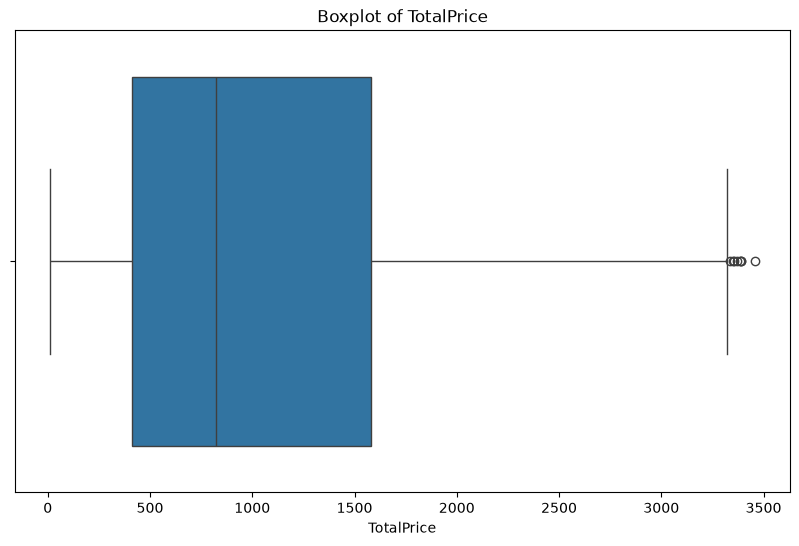

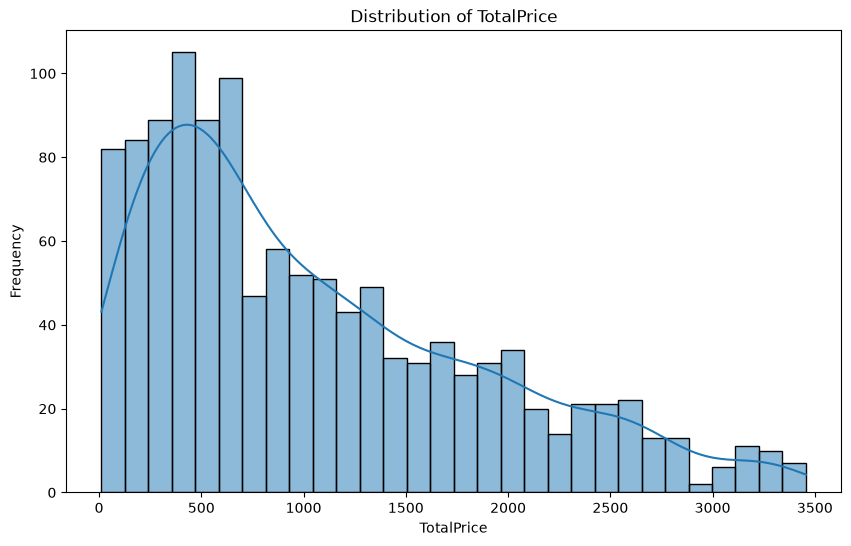

count    1200.000000
mean     1053.968300
std       819.856558
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3456.400000
Name: TotalPrice, dtype: float64


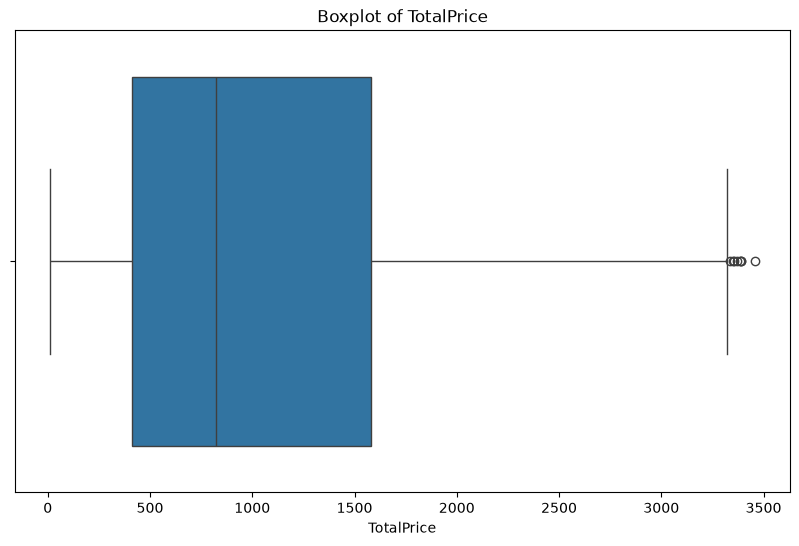

In [1]:
%pip install openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel('dataset for data analytics.xlsx')

#Data exploration
# df.head()
# df.tail()
# df.info()
# df.describe()
# df.columns

#Listing the columns we are analyzing
num_cols = ['Quantity', 'UnitPrice', 'TotalPrice']

#Create a summary table for mean, median, and count
stats = pd.DataFrame({"count": df[num_cols].count().round(2),
                      "mean": df[num_cols].mean().round(2),
                      "median": df[num_cols].median().round(2),
                      "std dev": df[num_cols].std().round(2)})
#Display the summary table
print(stats)

#Top 5 Selling Products
top_products = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).head(5)
print(top_products.round(2))
print()

#Monthly Revenue Trend Over The Time
df['Date'] = pd.to_datetime(df['Date'])
monthly_revenue = df.groupby([df['Date'].dt.to_period('M')])['TotalPrice'].sum().reset_index()

print(monthly_revenue.round(2))

#Calculate Q1 (25th percentile), Q3 (75th percentile), and IQR (Interquartile Range) for TotalPrice
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

#define upper and lower bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#Isolate outliers rows
outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]
print(outliers)

#Quick outlier visualization using boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['TotalPrice'])
plt.title('Boxplot of TotalPrice')
plt.xlabel('TotalPrice')
plt.show()

#Quick distribution visualization using histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['TotalPrice'], bins=30, kde=True)
plt.title('Distribution of TotalPrice')
plt.xlabel('TotalPrice')
plt.ylabel('Frequency')
plt.show()

#Calculate the key values for the summary statistics
summary_stats = df['TotalPrice'].describe()
print(summary_stats)


#Exporting data to excel
df.to_excel("cleaned_dataset.xlsx", index=False, sheet_name="Cleaned Data")

#save the plot as an image before displaying it
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['TotalPrice'])
plt.title('Boxplot of TotalPrice')
plt.xlabel('TotalPrice')
plt.savefig('boxplot_totalprice.png')

#export both data and stats into one excel file with multiple sheets
with pd.ExcelWriter("exported_data.xlsx") as writer:
    df.to_excel(writer, sheet_name="Cleaned Data", index=False)
    summary_stats.to_excel(writer, sheet_name="Summary Statistics")
